# Tarificación de seguros de auto con datos
**Autora:** Jessica Ojeda Arenas

## ¿Qué pregunta responde este proyecto?
Una aseguradora necesita cobrarle a cada cliente una prima acorde a su riesgo.
Si cobra lo mismo a todos, los conductores de bajo riesgo se van a la competencia
y se queda con los de alto riesgo (*selección adversa*).

El objetivo es estimar la **prima pura** de cada póliza, es decir, el costo esperado
de siniestros por año:

$$\text{Prima pura} = \underbrace{E[\text{N° siniestros por año}]}_{\text{frecuencia}} \times \underbrace{E[\text{costo por siniestro}]}_{\text{severidad}}$$

## Herramientas
| Etapa | Herramienta |
|---|---|
| Almacenamiento y exploración | **SQL** (SQL Server / SQLite) |
| Limpieza y modelos | **Python**: pandas, statsmodels, scikit-learn |
| Modelo actuarial clásico | **GLM** Poisson (frecuencia) y Gamma (severidad) |
| Modelo de machine learning | **Gradient Boosting** con pérdida Poisson |
| Visualización | Dashboard web + **Power BI** |

## Datos
`freMTPL2` (paquete CASdatasets): 677.991 pólizas de responsabilidad civil de autos
de una aseguradora francesa, observadas durante un año, más 26.444 montos de siniestros.
Es una base pública muy usada en la literatura actuarial para comparar modelos de tarificación.

In [1]:
import sqlite3
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_poisson_deviance

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})

PROYECTO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATOS, SQL, PBI = PROYECTO / "datos", PROYECTO / "sql", PROYECTO / "power-bi"
SEMILLA = 2026

## 1. Cargar los datos en una base SQL
Creamos las tablas con el script `sql/01_crear_tablas.sql` y cargamos los CSV.
Uso SQLite para que el proyecto se pueda reproducir sin instalar nada; las mismas
consultas corren en SQL Server (ver `sql/02_cargar_datos.sql`).

In [2]:
con = sqlite3.connect(":memory:")
con.executescript((SQL / "01_crear_tablas.sql").read_text(encoding="utf-8"))

polizas = pd.read_csv(DATOS / "polizas.csv")
siniestros = pd.read_csv(DATOS / "siniestros.csv")
polizas.to_sql("polizas", con, if_exists="append", index=False)
siniestros.to_sql("siniestros", con, if_exists="append", index=False)

pd.read_sql("SELECT 'polizas' AS tabla, COUNT(*) AS filas FROM polizas "
            "UNION ALL SELECT 'siniestros', COUNT(*) FROM siniestros", con)

,tabla,filas
0,polizas,677991
1,siniestros,26444


## 2. Análisis exploratorio en SQL
Ejecutamos cada consulta de `sql/03_analisis_exploratorio.sql`.

In [3]:
texto_sql = (SQL / "03_analisis_exploratorio.sql").read_text(encoding="utf-8")
consultas = {m.group(1): m.group(2).strip()
             for m in re.finditer(r"-- @consulta (\w+)\n(.*?;)", texto_sql, flags=re.S)}
resultados_sql = {nombre: pd.read_sql(q, con) for nombre, q in consultas.items()}
list(resultados_sql)

['control_calidad',
 'kpis_cartera',
 'frecuencia_por_edad',
 'frecuencia_por_bonus_malus',
 'severidad_por_combustible',
 'prima_pura_por_area',
 'concentracion_siniestros_grandes']

In [4]:
resultados_sql["control_calidad"]

,siniestros_declarados,siniestros_con_monto,polizas_con_siniestro_sin_monto,polizas_exposicion_mayor_1
0,26444,26444,0,1224


**Lectura:** hay pólizas que declaran siniestros pero no tienen monto cargado, y algunas
con exposición mayor a 1 año. Son problemas típicos de datos reales que hay que tratar
antes de modelar (paso 3).

In [5]:
resultados_sql["kpis_cartera"]

,polizas,anios_poliza,siniestros,frecuencia
0,677991,"358,483.0000",26444,0.0738


In [6]:
resultados_sql["frecuencia_por_edad"]

,tramo_edad,polizas,anios_poliza,siniestros,frecuencia
0,18-20,6816,"2,585.0000",617,0.2387
1,21-25,32077,"13,642.0000",1786,0.1309
2,26-30,65592,"29,180.0000",2379,0.0815
3,31-40,170094,"83,934.0000",5800,0.0691
4,41-50,165179,"88,133.0000",6660,0.0756
5,51-60,135010,"75,725.0000",5233,0.0691
6,61-70,63858,"38,329.0000",2359,0.0615
7,71+,39365,"26,955.0000",1610,0.0597


In [7]:
resultados_sql["frecuencia_por_bonus_malus"]

,tramo_bm,polizas,siniestros,frecuencia
0,50 (máximo bonus),384142,11592,0.0515
1,51-59,77080,3034,0.0762
2,60-79,118030,5750,0.1069
3,80-99,71415,3492,0.1171
4,100+ (malus),27324,2576,0.2625


In [8]:
resultados_sql["prima_pura_por_area"]

,area,anios_poliza,frecuencia,severidad,prima_pura
0,A,"61,966.0000",0.0543,"2,301.0000",124.9000
1,B,"43,011.0000",0.0612,"3,370.0000",206.3000
2,C,"104,443.0000",0.0679,"2,060.0000",139.9000
3,D,"77,117.0000",0.0837,"2,243.0000",187.9000
4,E,"63,817.0000",0.0959,"2,126.0000",204.0000
5,F,"8,129.0000",0.0952,"1,524.0000",145.1000


In [9]:
resultados_sql["concentracion_siniestros_grandes"]

,rango_monto,siniestros,pct_cantidad,pct_monto
0,1. < 1.000,8192,30.9800,5.6600
1,2. 1.000 - 5.000,16995,64.2700,42.7900
2,3. 5.000 - 20.000,1036,3.9200,14.8700
3,4. 20.000 - 100.000,180,0.6800,12.1300
4,5. > 100.000,41,0.1600,24.5500


**Lectura:**
- Los conductores jóvenes (18-25) tienen una frecuencia muy superior al resto.
- El Bonus-Malus ordena muy bien el riesgo: a peor historial, más siniestros.
- Las zonas urbanas (E, F) tienen más frecuencia que las rurales (A).
- Muy pocos siniestros grandes explican una parte enorme del costo total. Esto
  obliga a tratar los **siniestros grandes** por separado en el modelo de severidad.

## 3. Limpieza y preparación
Decisiones (estándar en la literatura sobre esta base):
- **Siniestros por póliza:** se topean en 4 (valores de 5 a 16 son muy probablemente errores).
- **Exposición:** se topea en 1 año (el período de observación es de un año).
- **Variables en tramos:** el GLM estima un factor por tramo, lo que permite capturar
  relaciones no lineales (por ejemplo, la curva en "U" de la edad) y da una tarifa
  fácil de leer: cada tramo tiene su recargo o descuento.

In [10]:
df = polizas.copy()
df["ClaimNb"] = df["ClaimNb"].clip(upper=4)
df["Exposure"] = df["Exposure"].clip(upper=1)

def tramos(serie, cortes, etiquetas):
    return pd.cut(serie, bins=cortes, labels=etiquetas, right=False).astype(str)

df["tramo_edad"] = tramos(df.DrivAge, [18, 21, 26, 31, 41, 51, 61, 71, 200],
                          ["18-20", "21-25", "26-30", "31-40", "41-50", "51-60", "61-70", "71+"])
df["tramo_antig"] = tramos(df.VehAge, [0, 1, 3, 6, 11, 16, 200],
                           ["0", "1-2", "3-5", "6-10", "11-15", "16+"])
df["tramo_bm"] = tramos(df.BonusMalus, [50, 51, 60, 70, 80, 100, 125, 1000],
                        ["50", "51-59", "60-69", "70-79", "80-99", "100-124", "125+"])
df["tramo_potencia"] = tramos(df.VehPower, [4, 6, 7, 8, 10, 100],
                              ["4-5", "6", "7", "8-9", "10+"])
df["frecuencia"] = df.ClaimNb / df.Exposure

VARIABLES = {
    "tramo_edad": "Edad del conductor",
    "tramo_antig": "Antigüedad del vehículo",
    "tramo_bm": "Bonus-Malus",
    "tramo_potencia": "Potencia del vehículo",
    "VehGas": "Combustible",
    "Area": "Zona (A rural – F urbana)",
    "VehBrand": "Marca (anonimizada)",
    "Region": "Región",
}

ORIGEN_TRAMO = {"tramo_edad": "DrivAge", "tramo_antig": "VehAge",
                "tramo_bm": "BonusMalus", "tramo_potencia": "VehPower"}

def niveles_ordenados(v):
    """Tramos en orden natural (18-20, 21-25, ...); el resto, alfabético."""
    if v in ORIGEN_TRAMO:
        return list(df.groupby(v)[ORIGEN_TRAMO[v]].min().sort_values().index)
    return sorted(df[v].unique(), key=lambda x: (len(x), x))

# Nivel base de cada variable = el de mayor exposición (su factor vale 1)
BASE = {v: df.groupby(v).Exposure.sum().idxmax() for v in VARIABLES}
BASE

{'tramo_edad': '41-50',
 'tramo_antig': '6-10',
 'tramo_bm': '50',
 'tramo_potencia': '4-5',
 'VehGas': 'Regular',
 'Area': 'C',
 'VehBrand': 'B1',
 'Region': 'Centre'}

### Análisis univariado (one-way)
Frecuencia observada por tramo. Es la primera mirada que hace un actuario antes de modelar.

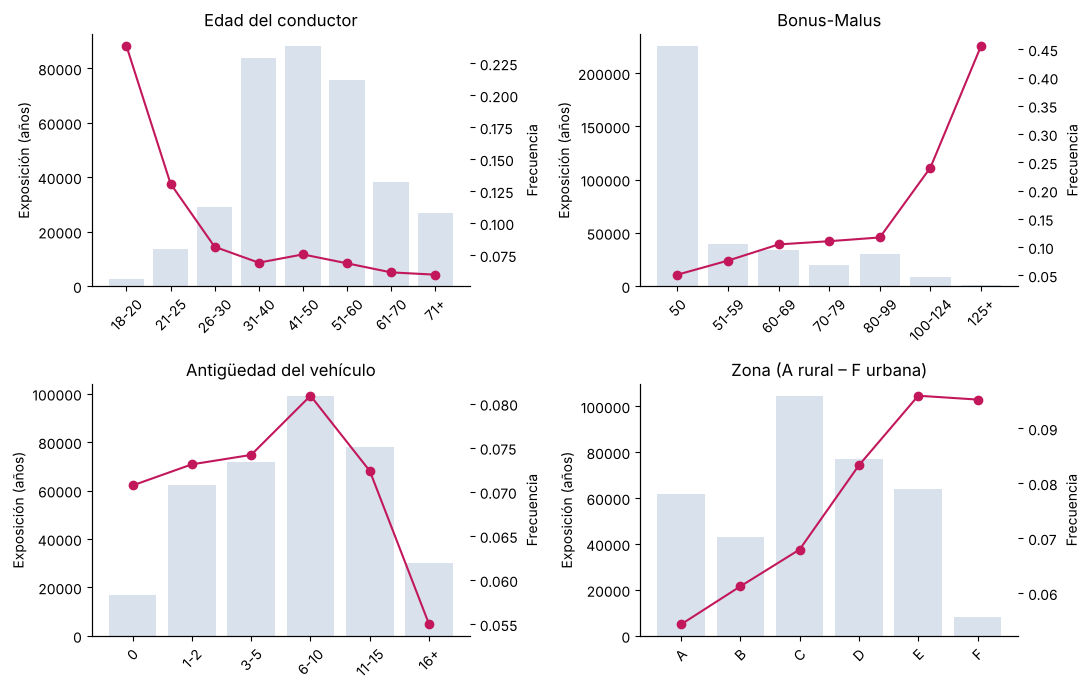

In [11]:
def one_way(data, var):
    t = data.groupby(var).agg(exposicion=("Exposure", "sum"), siniestros=("ClaimNb", "sum"))
    t["frecuencia"] = t.siniestros / t.exposicion
    return t.reindex(niveles_ordenados(var))

fig, ejes = plt.subplots(2, 2, figsize=(11, 7))
for eje, var in zip(ejes.flat, ["tramo_edad", "tramo_bm", "tramo_antig", "Area"]):
    t = one_way(df, var)
    eje.bar(t.index, t.exposicion, color="#d9e2ec")
    eje2 = eje.twinx()
    eje2.plot(t.index, t.frecuencia, color="#c2185b", marker="o")
    eje.set_title(VARIABLES[var]); eje.tick_params(axis="x", rotation=45)
    eje.set_ylabel("Exposición (años)"); eje2.set_ylabel("Frecuencia")
plt.tight_layout(); plt.show()

## 4. Separar entrenamiento y prueba
El 80 % de las pólizas se usa para ajustar los modelos y el 20 % restante solo para
evaluarlos. Así medimos cómo predicen sobre clientes que el modelo **no vio**.

In [12]:
train, test = train_test_split(df, test_size=0.2, random_state=SEMILLA)
print(f"Entrenamiento: {len(train):,} pólizas | Prueba: {len(test):,} pólizas")

Entrenamiento: 542,392 pólizas | Prueba: 135,599 pólizas


## 5. Modelo de frecuencia: GLM Poisson
El número de siniestros $N_i$ de la póliza $i$ se modela como Poisson:

$$N_i \sim \text{Poisson}(\lambda_i \cdot e_i), \qquad \log(\lambda_i) = \beta_0 + \sum_j \beta_j x_{ij}$$

- $e_i$ es la exposición: una póliza de 6 meses tiene la mitad de chances de tener un siniestro.
  Entra como **offset** $\log(e_i)$.
- Al usar link logarítmico, el modelo es **multiplicativo**: cada $e^{\beta_j}$ es un
  **factor de tarifa** (relatividad). Un factor de 1,30 significa un recargo del 30 % frente al tramo base.

In [13]:
def formula(variables):
    return " + ".join(f"C({v}, Treatment(reference='{BASE[v]}'))" for v in variables)

glm_freq = smf.glm(
    "ClaimNb ~ " + formula(VARIABLES),
    data=train,
    family=sm.families.Poisson(),
    offset=np.log(train.Exposure),
).fit()
print(glm_freq.summary().tables[0])

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542392
Model:                            GLM   Df Residuals:                   542332
Model Family:                 Poisson   Df Model:                           59
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -85298.
Date:                Fri, 02 Oct 2026   Deviance:                   1.3016e+05
Time:                        23:00:06   Pearson chi2:                 9.35e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01230
Covariance Type:            nonrobust                                         


### Factores de tarifa (relatividades) del GLM de frecuencia

In [14]:
def relatividades(modelo, variables):
    filas = []
    for v in variables:
        for nivel in niveles_ordenados(v):
            clave = f"C({v}, Treatment(reference='{BASE[v]}'))[T.{nivel}]"
            coef = modelo.params.get(clave, 0.0)
            p = modelo.pvalues.get(clave, np.nan)
            filas.append({"variable": v, "nivel": nivel, "factor": np.exp(coef), "p_valor": p})
    return pd.DataFrame(filas)

rel_freq = relatividades(glm_freq, VARIABLES)
frecuencia_base = np.exp(glm_freq.params["Intercept"])
print(f"Frecuencia del perfil base: {frecuencia_base:.4f} siniestros por año")
rel_freq[rel_freq.variable.isin(["tramo_edad", "tramo_bm", "Area"])]

Frecuencia del perfil base: 0.0495 siniestros por año


,variable,nivel,factor,p_valor
0,tramo_edad,18-20,1.1011,0.0591
1,tramo_edad,21-25,0.7159,0.0000
2,tramo_edad,26-30,0.5716,0.0000
3,tramo_edad,31-40,0.6948,0.0000
4,tramo_edad,41-50,1.0000,NaN
5,tramo_edad,51-60,0.9631,0.0717
6,tramo_edad,61-70,0.9180,0.0016
7,tramo_edad,71+,0.9698,0.3312
14,tramo_bm,50,1.0000,NaN
15,tramo_bm,51-59,1.6391,0.0000


**Lectura:**
- El **Bonus-Malus** es la variable más fuerte: el tramo 125+ tiene unas 10 veces la
  frecuencia del máximo bonus, aun con todo lo demás fijo.
- La zona sigue importando (F urbana ≈ +28 % frente a C), pero mucho menos que en el
  análisis univariado.
- **Sorpresa:** en el análisis univariado los conductores de 18-20 tenían 3 veces la
  frecuencia del tramo 41-50, pero en el GLM su factor es apenas 1,10. ¿Por qué? Veamos
  la siguiente tabla.

In [15]:
df.groupby("tramo_edad").BonusMalus.mean().reindex(niveles_ordenados("tramo_edad")).round(0).to_frame("Bonus-Malus promedio")

,Bonus-Malus promedio
tramo_edad,
18-20,95.0000
21-25,88.0000
26-30,74.0000
31-40,61.0000
41-50,55.0000
51-60,54.0000
61-70,53.0000
71+,52.0000


En Francia, los conductores nuevos **empiezan con Bonus-Malus 100** y lo bajan año a año
si no chocan. Entonces el Bonus-Malus ya "sabe" quién es joven: las dos variables están
**correlacionadas** y el GLM le asigna el efecto a la que mejor lo explica. Es un ejemplo
claro de por qué no alcanza con mirar tablas de a una variable: hay que pensar el efecto
**conjunto**. Para la tarifa final, lo que importa es la combinación: un conductor de
18-20 con Bonus-Malus 100 sigue pagando muchísimo más que el perfil base (ver punto 9).

## 6. Modelo de severidad: GLM Gamma + tratamiento de siniestros grandes
- Los montos son positivos y asimétricos, por eso se usa una distribución **Gamma** con link log.
- Los siniestros grandes son muy pocos pero muy caros: si entran al modelo, unos pocos casos
  distorsionan todos los factores. Se **topean** en el percentil 99 y el exceso se reparte
  como un **recargo por siniestros grandes** igual para toda la cartera.

In [16]:
TOPE = siniestros.ClaimAmount.quantile(0.99)
sev = siniestros.assign(monto_topeado=siniestros.ClaimAmount.clip(upper=TOPE))
sev_pol = (sev.groupby("IDpol")
              .agg(n=("ClaimAmount", "size"), monto=("ClaimAmount", "sum"), monto_top=("monto_topeado", "sum"))
              .reset_index()
              .merge(df, on="IDpol"))
sev_pol["sev_media_top"] = sev_pol.monto_top / sev_pol.n
sev_train = sev_pol[sev_pol.IDpol.isin(train.IDpol)]

recargo_grandes = sev_train.monto.sum() / sev_train.monto_top.sum()
print(f"Tope (percentil 99): {TOPE:,.0f} EUR")
print(f"Recargo por siniestros grandes: {recargo_grandes:.3f} (+{(recargo_grandes - 1):.1%})")

VARIABLES_SEV = ["tramo_edad", "tramo_antig", "tramo_bm", "VehGas", "Area"]
glm_sev = smf.glm(
    "sev_media_top ~ " + formula(VARIABLES_SEV),
    data=sev_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    var_weights=sev_train.n,
).fit()
rel_sev = relatividades(glm_sev, VARIABLES_SEV)
severidad_base = np.exp(glm_sev.params["Intercept"])
print(f"Severidad topeada del perfil base: {severidad_base:,.0f} EUR")
rel_sev[rel_sev.p_valor < 0.05]

Tope (percentil 99): 16,451 EUR
Recargo por siniestros grandes: 1.514 (+51.4%)


Severidad topeada del perfil base: 1,433 EUR


,variable,nivel,factor,p_valor
0,tramo_edad,18-20,1.3111,0.0001
7,tramo_edad,71+,1.1131,0.0133
17,tramo_bm,70-79,1.1359,0.0008
18,tramo_bm,80-99,1.0712,0.0475
19,tramo_bm,100-124,1.1261,0.0056
26,Area,D,1.0601,0.0292
27,Area,E,1.0734,0.0093
28,Area,F,0.8743,0.0237


**Lectura:** las variables explican mucho menos la severidad que la frecuencia
(pocos factores son significativos). Es un resultado habitual: *cuántas veces* choca
alguien depende mucho de su perfil; *cuánto cuesta* cada choque es más aleatorio.

## 7. Modelo de machine learning: Gradient Boosting
Un **Gradient Boosting** combina cientos de árboles de decisión chicos. Usamos la
pérdida **Poisson** (la misma lógica que el GLM) y la exposición como peso, para que la
comparación sea justa. Puede capturar interacciones (por ejemplo, joven *y* auto potente)
que el GLM no ve, pero es una "caja negra": no da una tabla de factores.

In [17]:
NUM = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]
CAT = ["VehBrand", "VehGas", "Area", "Region"]

def matriz(data):
    X = data[NUM + CAT].copy()
    for c in CAT:
        X[c] = pd.Categorical(X[c], categories=sorted(df[c].unique()))
    return X

gbm = HistGradientBoostingRegressor(
    loss="poisson", learning_rate=0.05, max_iter=400, max_leaf_nodes=31,
    min_samples_leaf=200, categorical_features="from_dtype",
    early_stopping=True, validation_fraction=0.1, random_state=SEMILLA,
)
gbm.fit(matriz(train), train.frecuencia, sample_weight=train.Exposure)
print(f"Árboles usados: {gbm.n_iter_}")

Árboles usados: 69


## 8. Comparación de modelos (sobre los datos de prueba)
- **Desvío Poisson medio:** error adaptado a conteos. Cuanto **más bajo**, mejor.
- **Gini:** mide si el modelo **ordena** bien a los clientes de menor a mayor riesgo.
  Cuanto **más alto**, mejor. Para tarificar, ordenar bien es lo más importante.

In [18]:
test = test.copy()
test["pred_nulo"] = (train.ClaimNb.sum() / train.Exposure.sum())
test["pred_glm"] = glm_freq.predict(test, offset=np.zeros(len(test)))
test["pred_gbm"] = gbm.predict(matriz(test))

def gini(real, pred, expo):
    orden = np.argsort(pred)
    x = np.concatenate([[0], np.cumsum(expo.values[orden]) / expo.sum()])
    y = np.concatenate([[0], np.cumsum(real.values[orden]) / real.sum()])
    return 1 - 2 * np.trapezoid(y, x), x, y

metricas, curvas = [], {}
for nombre, col in [("Modelo nulo (misma tarifa para todos)", "pred_nulo"),
                    ("GLM Poisson", "pred_glm"), ("Gradient Boosting", "pred_gbm")]:
    dev = mean_poisson_deviance(test.frecuencia, test[col], sample_weight=test.Exposure)
    g, x, y = gini(test.ClaimNb, test[col] + np.random.default_rng(0).normal(0, 1e-9, len(test)), test.Exposure)
    metricas.append({"modelo": nombre, "desvio_poisson": dev, "gini": g})
    curvas[nombre] = (x, y)
metricas = pd.DataFrame(metricas)
metricas["mejora_desvio_vs_nulo"] = 1 - metricas.desvio_poisson / metricas.desvio_poisson.iloc[0]
metricas

,modelo,desvio_poisson,gini,mejora_desvio_vs_nulo
0,Modelo nulo (misma tarifa para todos),0.4794,-0.0013,0.0000
1,GLM Poisson,0.4564,0.2917,0.0478
2,Gradient Boosting,0.4486,0.3231,0.0642


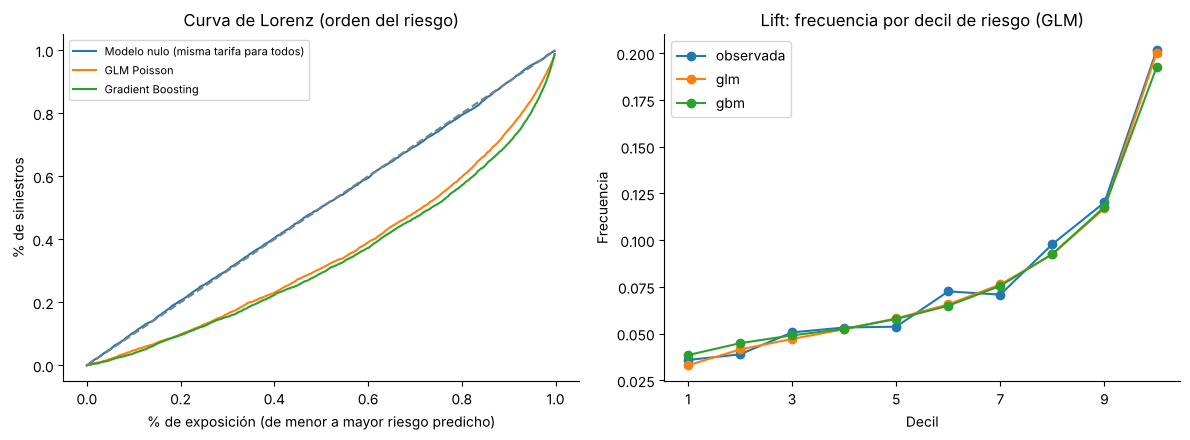

,observada,glm,gbm
decil,,,
1,0.0359,0.0330,0.0385
2,0.0389,0.0415,0.0449
3,0.0507,0.0472,0.0491
4,0.0533,0.0523,0.0525
5,0.0537,0.0582,0.0578
6,0.0726,0.0656,0.0649
7,0.0709,0.0763,0.0756
8,0.0979,0.0924,0.0926
9,0.1202,0.1170,0.1178


In [19]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
for nombre, (x, y) in curvas.items():
    paso = max(1, len(x) // 400)
    ejes[0].plot(x[::paso], y[::paso], label=nombre)
ejes[0].plot([0, 1], [0, 1], ls="--", c="grey")
ejes[0].set(title="Curva de Lorenz (orden del riesgo)",
            xlabel="% de exposición (de menor a mayor riesgo predicho)", ylabel="% de siniestros")
ejes[0].legend(fontsize=8)

test["decil"] = pd.qcut(test.pred_glm.rank(method="first"), 10, labels=range(1, 11))
lift = test.groupby("decil", observed=True).apply(lambda g: pd.Series({
    "observada": g.ClaimNb.sum() / g.Exposure.sum(),
    "glm": np.average(g.pred_glm, weights=g.Exposure),
    "gbm": np.average(g.pred_gbm, weights=g.Exposure),
}), include_groups=False)
lift.plot(ax=ejes[1], marker="o")
ejes[1].set(title="Lift: frecuencia por decil de riesgo (GLM)", xlabel="Decil", ylabel="Frecuencia")
plt.tight_layout(); plt.show()
lift

## 9. Prima pura y ejemplos de perfiles
$$\text{Prima pura} = \lambda_{\text{base}} \prod_j f^{\text{frec}}_j \;\times\; \mu_{\text{base}} \prod_j f^{\text{sev}}_j \;\times\; \text{recargo grandes}$$

In [20]:
def prima_pura(perfil):
    f = frecuencia_base * np.prod([rel_freq.query("variable == @v and nivel == @perfil[@v]").factor.iloc[0] for v in VARIABLES])
    s = severidad_base * np.prod([rel_sev.query("variable == @v and nivel == @perfil[@v]").factor.iloc[0] for v in VARIABLES_SEV])
    return f, s * recargo_grandes, f * s * recargo_grandes

perfil_base = dict(BASE)
joven = {**BASE, "tramo_edad": "18-20", "tramo_bm": "100-124", "Area": "E", "tramo_antig": "0"}
experimentado = {**BASE, "tramo_edad": "51-60", "tramo_bm": "50", "Area": "B"}
pd.DataFrame([dict(zip(["frecuencia", "severidad", "prima_pura"], prima_pura(p)), perfil=n)
              for n, p in [("Perfil base", perfil_base), ("Joven, sin historial, zona urbana", joven),
                           ("Conductor experimentado, máximo bonus, zona rural", experimentado)]]).set_index("perfil")

,frecuencia,severidad,prima_pura
perfil,,,
Perfil base,0.0495,"2,169.6801",107.3313
"Joven, sin historial, zona urbana",0.3451,"3,732.5248","1,288.2467"
"Conductor experimentado, máximo bonus, zona rural",0.0441,"2,239.6564",98.7761


### Control: ¿la tarifa cubre el costo total?
Un buen modelo de tarificación tiene que ser **equilibrado**: la suma de primas puras
debería parecerse a la suma de siniestros observados. Lo controlamos en dos niveles:
1. Con los montos **topeados** (lo que explican los modelos).
2. Con los montos **totales** (agregando el recargo por siniestros grandes).

In [21]:
monto_por_pol = siniestros.groupby("IDpol").ClaimAmount.sum()
monto_top_por_pol = sev.groupby("IDpol").monto_topeado.sum()
filas = []
for nombre, d in [("Entrenamiento", train), ("Prueba", test)]:
    frec = glm_freq.predict(d, offset=np.zeros(len(d)))
    sev_top = np.exp(glm_sev.predict(d, which="linear"))
    prima_top = (frec * sev_top * d.Exposure).sum()
    costo_top = d.IDpol.map(monto_top_por_pol).fillna(0).sum()
    costo_total = d.IDpol.map(monto_por_pol).fillna(0).sum()
    filas.append({"datos": nombre,
                  "cociente_topeado": prima_top / costo_top,
                  "cociente_total": prima_top * recargo_grandes / costo_total,
                  "siniestros_mayores_100k": int((d.IDpol.map(monto_por_pol).fillna(0) > 100_000).sum())})
equilibrio = pd.DataFrame(filas).set_index("datos")
equilibrio

,cociente_topeado,cociente_total,siniestros_mayores_100k
datos,,,
Entrenamiento,0.9984,0.9984,40
Prueba,0.9757,1.2640,2


**Lectura:**
- Con montos topeados, la tarifa queda **equilibrada** en entrenamiento y en prueba
  (cocientes cercanos a 1): los modelos de frecuencia y severidad funcionan bien.
- Con montos totales, la prueba muestra una prima ~25 % superior al costo. No es un error
  del modelo: en entrenamiento cayeron 40 siniestros de más de 100.000 EUR (uno de más de
  4 millones) y en prueba solo 2. Los siniestros grandes son tan volátiles que en una
  muestra chica pueden aparecer o no. Por eso en la práctica el recargo por grandes se
  calcula con **varios años** de historia o con modelos de valores extremos, y se
  complementa con **reaseguro**.

## 10. Conclusiones
1. El **Bonus-Malus** es la variable que más diferencia el riesgo de frecuencia, y además
   absorbe gran parte del efecto de la edad (los conductores nuevos empiezan en 100).
2. El **Gradient Boosting** ajusta y ordena algo mejor que el GLM (Gini 0,32 vs 0,29),
   porque detecta interacciones y relaciones no lineales por su cuenta.
3. Aun así, el **GLM** entrega una tabla de factores que se puede explicar a un regulador,
   a un área comercial o a un cliente, y por eso sigue siendo el estándar en tarificación.
   El Gradient Boosting sirve como **referencia**: la diferencia de Gini indica cuánto
   se podría ganar agregando interacciones al GLM.
4. La **severidad** es difícil de predecir con estas variables, y los **siniestros grandes**
   son tan volátiles que requieren un tratamiento aparte (tope + recargo, reaseguro).

**Limitaciones y próximos pasos:** la base no identifica a un mismo asegurado con varias pólizas
(podría haber repetidos entre entrenamiento y prueba); se podría probar validación cruzada,
interacciones edad × potencia en el GLM, y un modelo específico de siniestros grandes
(teoría de valores extremos).

## 11. Exportar resultados (dashboard web y Power BI)

In [22]:
PBI.mkdir(exist_ok=True)
test["costo_real"] = test.IDpol.map(monto_por_pol).fillna(0)
test["prima_glm"] = test.pred_glm * np.exp(glm_sev.predict(test, which="linear")) * recargo_grandes * test.Exposure
oneway = pd.concat([one_way(df, v).reset_index().rename(columns={v: "nivel"}).assign(variable=v, nombre=VARIABLES[v])
                    for v in VARIABLES])
oneway.to_csv(PBI / "frecuencia_por_variable.csv", index=False)
rel_freq.assign(modelo="frecuencia").to_csv(PBI / "factores_glm_frecuencia.csv", index=False)
rel_sev.assign(modelo="severidad").to_csv(PBI / "factores_glm_severidad.csv", index=False)
metricas.to_csv(PBI / "comparacion_modelos.csv", index=False)
lift.reset_index().to_csv(PBI / "lift_por_decil.csv", index=False)
(test[["IDpol", "tramo_edad", "tramo_bm", "Area", "VehGas", "Region", "Exposure", "ClaimNb",
       "pred_glm", "pred_gbm", "prima_glm", "costo_real", "decil"]]
     .sample(20000, random_state=SEMILLA)
     .to_csv(PBI / "predicciones_muestra.csv", index=False))

def r(x, n=4):
    return float(round(x, n))

resultado_web = {
    "kpis": resultados_sql["kpis_cartera"].iloc[0].to_dict(),
    "severidad_media": r(siniestros.ClaimAmount.mean(), 0),
    "tope": r(TOPE, 0),
    "recargo_grandes": r(recargo_grandes),
    "frecuencia_base": r(frecuencia_base, 5),
    "severidad_base": r(severidad_base, 1),
    "variables": VARIABLES,
    "base": BASE,
    "oneway": {v: [{"nivel": n, "exposicion": r(e, 0), "frecuencia": r(f)}
                   for n, e, f in oneway.query("variable == @v")[["nivel", "exposicion", "frecuencia"]].values]
               for v in VARIABLES},
    "factores_frecuencia": {v: {n: r(f) for n, f in rel_freq.query("variable == @v")[["nivel", "factor"]].values} for v in VARIABLES},
    "factores_severidad": {v: {n: r(f) for n, f in rel_sev.query("variable == @v")[["nivel", "factor"]].values} for v in VARIABLES_SEV},
    "metricas": [{k: (r(v) if isinstance(v, float) else v) for k, v in fila.items()} for fila in metricas.to_dict("records")],
    "lorenz": {n: {"x": [r(v, 3) for v in x[::max(1, len(x) // 100)]] + [1.0],
                   "y": [r(v, 3) for v in y[::max(1, len(y) // 100)]] + [1.0]} for n, (x, y) in curvas.items()},
    "lift": [{"decil": int(d), **{k: r(v) for k, v in fila.items()}} for d, fila in lift.iterrows()],
    "concentracion": resultados_sql["concentracion_siniestros_grandes"].to_dict("records"),
    "equilibrio": {k: {c: r(v, 3) for c, v in fila.items()} for k, fila in equilibrio.iterrows()},
}
(PROYECTO / "resultados.js").write_text(
    "// Generado automáticamente por notebooks/tarificacion_seguros_auto.ipynb\n"
    "window.RESULTADOS = " + json.dumps(resultado_web, ensure_ascii=False, default=float) + ";\n",
    encoding="utf-8")
print("Listo: resultados.js y CSV para Power BI exportados.")

Listo: resultados.js y CSV para Power BI exportados.
